# Этап 6. Поиск похожего блюда на замену (kNN)

**Цель этапа:** для блюда которому классификатор сказал "нужна замена" — найти наиболее похожее блюдо той же категории, которое лучше подходит под цель пользователя.

**Логика работы:**
1. Пользователь вводит блюдо + количество граммов + цель
2. КБЖУ пересчитывается на указанную порцию
3. Проверяем нужна ли замена (через target-метку из разметки)
4. Если нужна — kNN ищет ближайших соседей среди блюд той же категории
5. Из соседей выбирается то, у которого target=0 (замена не нужна)

**Почему kNN:** алгоритм k ближайших соседей находит блюда с наиболее похожим нутриционным профилем в пространстве 7 признаков.

## 1. Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('../data/russian_food_labeled.csv')

# Загружаем лучшие модели
with open('../data/best_models.pkl', 'rb') as f:
    best_models = pickle.load(f)

targets = ['target_weightloss', 'target_gainmass', 'target_balance', 'target_sugar']
labels  = ['Похудение', 'Набор массы', 'Баланс/ЗОЖ', 'Контроль сахара']
label_to_target = dict(zip(labels, targets))

print('Данные загружены успешно')
print('Блюд в датасете:', len(df))
print('Категорий:', df['Category'].nunique())
print('Категории:', sorted(df['Category'].unique()))

Данные загружены успешно
Блюд в датасете: 400
Категорий: 17
Категории: ['Бобовые', 'Выпечка', 'Гарнир', 'Десерт', 'Европейское', 'Завтрак', 'Крупа', 'Молочное', 'Мясо', 'Напиток', 'Овощ', 'Орехи', 'Рыба', 'Салат', 'Суп', 'Фрукт', 'Яйца']


## 2. Нутриционные признаки для kNN

In [2]:

nutrition_features = [
    'Calories (kcal)',
    'Protein (g)',
    'Carbohydrates (g)',
    'Fat (g)',
    'Fiber (g)',
    'Sugars (g)',
    'Sodium (mg)'
]

print('Признаки для kNN (7 нутриционных характеристик):')
for f in nutrition_features:
    print(f'  - {f}')

Признаки для kNN (7 нутриционных характеристик):
  - Calories (kcal)
  - Protein (g)
  - Carbohydrates (g)
  - Fat (g)
  - Fiber (g)
  - Sugars (g)
  - Sodium (mg)


## 3. Функция пересчёта КБЖУ на порцию

Все данные в датасете указаны на 100г. Пересчитываем на фактическую порцию пользователя.

In [3]:
def calculate_portion(dish_row, grams):
    """Пересчитывает КБЖУ блюда на заданное количество граммов."""
    factor = grams / 100
    portion = {}
    for feat in nutrition_features:
        portion[feat] = round(float(dish_row[feat]) * factor, 1)
    return portion

# Пример пересчёта
dish = df[df['Food_Item'] == 'Борщ'].iloc[0]
print('Борщ на 100г:')
for f in nutrition_features:
    print(f'  {f}: {dish[f]}')

print()
print('Борщ на порцию 300г:')
portion = calculate_portion(dish, 300)
for k, v in portion.items():
    print(f'  {k}: {v}')

Борщ на 100г:
  Calories (kcal): 50
  Protein (g): 2.8
  Carbohydrates (g): 5.2
  Fat (g): 2.0
  Fiber (g): 1.2
  Sugars (g): 2.0
  Sodium (mg): 480

Борщ на порцию 300г:
  Calories (kcal): 150.0
  Protein (g): 8.4
  Carbohydrates (g): 15.6
  Fat (g): 6.0
  Fiber (g): 3.6
  Sugars (g): 6.0
  Sodium (mg): 1440.0


## 4. Основная функция поиска замены

In [ ]:
def find_replacement(food_item, grams, goal, k=10):
    """
    Находит замену для блюда под заданную цель пользователя.

    Параметры:
        food_item: название блюда
        grams: количество граммов порции
        goal: цель пользователя (Похудение / Набор массы / Баланс/ЗОЖ / Контроль сахара)
        k: количество ближайших соседей для поиска

    Возвращает словарь с результатом и рекомендацией.
    """
    target_col = label_to_target[goal]

    # Находим блюдо в датасете
    dish_rows = df[df['Food_Item'] == food_item]
    if len(dish_rows) == 0:
        return {'error': f'Блюдо "{food_item}" не найдено в датасете'}

    dish = dish_rows.iloc[0]
    category = dish['Category']
    needs_replacement = int(dish[target_col]) == 1

    # Пересчитываем КБЖУ на порцию
    original_portion = calculate_portion(dish, grams)

    # Если замена не нужна — возвращаем сразу
    if not needs_replacement:
        return {
            'food_item': food_item,
            'grams': grams,
            'goal': goal,
            'category': category,
            'needs_replacement': False,
            'original_portion': original_portion,
            'replacement': None,
            'message': 'Это блюдо подходит для вашей цели — замена не нужна!'
        }

    # Фильтруем блюда той же категории исключая само блюдо
    category_mask = (df['Category'] == category) & (df['Food_Item'] != food_item)
    df_category = df[category_mask].reset_index(drop=True)

    if len(df_category) < 2:
        return {
            'food_item': food_item,
            'grams': grams,
            'goal': goal,
            'category': category,
            'needs_replacement': True,
            'original_portion': original_portion,
            'replacement': None,
            'message': f'В категории "{category}" недостаточно блюд для поиска замены'
        }

    # Масштабируем признаки
    scaler = StandardScaler()
    X_category = scaler.fit_transform(df_category[nutrition_features].astype(float))
    X_dish = scaler.transform(
        pd.DataFrame([original_portion])[nutrition_features].astype(float)
    )

    # kNN поиск
    n_neighbors = min(k, len(df_category))
    knn = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
    knn.fit(X_category)
    distances, indices = knn.kneighbors(X_dish)

    # Ищем подходящую замену среди соседей (target = 0)
    candidates = []
    for dist, idx in zip(distances[0], indices[0]):
        neighbor = df_category.iloc[idx]
        if int(neighbor[target_col]) == 0:
            candidates.append({
                'Food_Item':       neighbor['Food_Item'],
                'Category':        neighbor['Category'],
                'distance':        round(dist, 3),
                'portion':         calculate_portion(neighbor, grams)
            })

    if not candidates:
        return {
            'food_item': food_item,
            'grams': grams,
            'goal': goal,
            'category': category,
            'needs_replacement': True,
            'original_portion': original_portion,
            'replacement': None,
            'message': f'Среди {n_neighbors} ближайших блюд категории "{category}" не найдено подходящей замены'
        }

    best = candidates[0]

    return {
        'food_item':          food_item,
        'grams':              grams,
        'goal':               goal,
        'category':           category,
        'needs_replacement':  True,
        'original_portion':   original_portion,
        'replacement':        best['Food_Item'],
        'replacement_portion': best['portion'],
        'distance':           best['distance'],
        'all_candidates':     candidates,
        'message':            f'Рекомендуем заменить на: {best["Food_Item"]}'
    }



Функция поиска замены готова


## 5. Тестирование на примерах

In [5]:
def print_result(result):
    """Красиво выводит результат поиска замены."""
    if 'error' in result:
        print(f'Ошибка: {result["error"]}')
        return

    print(f'Блюдо:     {result["food_item"]} ({result["grams"]}г)')
    print(f'Цель:      {result["goal"]}')
    print(f'Категория: {result["category"]}')
    print()

    if not result['needs_replacement']:
        print('Статус:  Замена не нужна — блюдо подходит для вашей цели!')
        print()
        print('КБЖУ на порцию:')
        for k, v in result['original_portion'].items():
            print(f'  {k}: {v}')
    else:
        print('Статус:  Нужна замена')
        print()
        print('КБЖУ оригинала на порцию:')
        for k, v in result['original_portion'].items():
            print(f'  {k}: {v}')
        print()
        if result['replacement']:
            print(f'Рекомендация:  {result["replacement"]}')
            print()
            print('КБЖУ замены на ту же порцию:')
            for k, v in result['replacement_portion'].items():
                print(f'  {k}: {v}')
        else:
            print(f'  {result["message"]}')
    print('=' * 55)

# Тест 1: Шоколадный торт при похудении
print('ТЕСТ 1:')
result1 = find_replacement('Шоколадный торт', 150, 'Похудение')
print_result(result1)

# Тест 2: Борщ при наборе массы
print('ТЕСТ 2:')
result2 = find_replacement('Борщ', 300, 'Набор массы')
print_result(result2)

# Тест 3: Пельмени при контроле сахара
print('ТЕСТ 3:')
result3 = find_replacement('Пельмени', 200, 'Контроль сахара')
print_result(result3)

# Тест 4: Гречка при похудении (не нужна замена)
print('ТЕСТ 4:')
result4 = find_replacement('Гречневая каша на воде', 200, 'Похудение')
print_result(result4)

ТЕСТ 1:
Блюдо:     Шоколадный торт (150г)
Цель:      Похудение
Категория: Десерт

Статус:  Нужна замена

КБЖУ оригинала на порцию:
  Calories (kcal): 577.5
  Protein (g): 8.2
  Carbohydrates (g): 78.8
  Fat (g): 27.8
  Fiber (g): 2.2
  Sugars (g): 57.8
  Sodium (mg): 270.0

  Среди 10 ближайших блюд категории "Десерт" не найдено подходящей замены
ТЕСТ 2:
Блюдо:     Борщ (300г)
Цель:      Набор массы
Категория: Суп

Статус:  Нужна замена

КБЖУ оригинала на порцию:
  Calories (kcal): 150.0
  Protein (g): 8.4
  Carbohydrates (g): 15.6
  Fat (g): 6.0
  Fiber (g): 3.6
  Sugars (g): 6.0
  Sodium (mg): 1440.0

Рекомендация:  Гороховый суп

КБЖУ замены на ту же порцию:
  Calories (kcal): 345.0
  Protein (g): 22.5
  Carbohydrates (g): 42.0
  Fat (g): 10.5
  Fiber (g): 13.5
  Sugars (g): 3.0
  Sodium (mg): 1560.0
ТЕСТ 3:
Блюдо:     Пельмени (200г)
Цель:      Контроль сахара
Категория: Мясо

Статус:  Нужна замена

КБЖУ оригинала на порцию:
  Calories (kcal): 550.0
  Protein (g): 24.0
  Carbohydra

## 6. Визуализация — сравнение оригинала и замены

Замена не найдена — нечего сравнивать


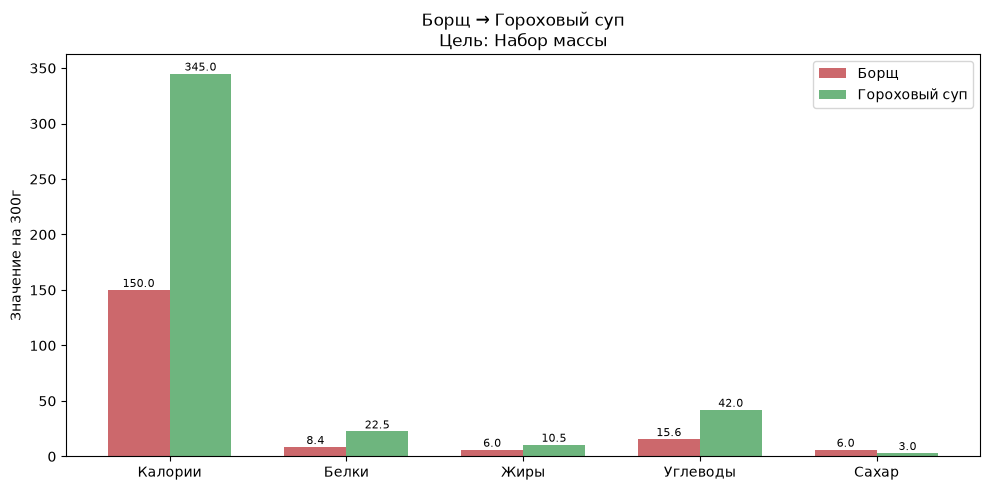

In [6]:
def visualize_comparison(result):
    """Строит столбчатую диаграмму сравнения оригинала и замены."""
    if not result.get('replacement'):
        if not result.get('needs_replacement'):
            print(f'{result["food_item"]} подходит — нечего сравнивать')
        else:
            print('Замена не найдена — нечего сравнивать')
        return

    features_to_show = ['Calories (kcal)', 'Protein (g)', 'Fat (g)',
                        'Carbohydrates (g)', 'Sugars (g)']
    short_names      = ['Калории', 'Белки', 'Жиры', 'Углеводы', 'Сахар']

    orig_vals = [result['original_portion'].get(f, 0) for f in features_to_show]
    repl_vals = [result['replacement_portion'].get(f, 0) for f in features_to_show]

    x     = np.arange(len(short_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - width/2, orig_vals, width,
                   label=result['food_item'], color='#C44E52', alpha=0.85)
    bars2 = ax.bar(x + width/2, repl_vals, width,
                   label=result['replacement'], color='#55A868', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(short_names)
    ax.set_ylabel(f'Значение на {result["grams"]}г')
    ax.set_title(
        f'{result["food_item"]} → {result["replacement"]}\n'
        f'Цель: {result["goal"]}'
    )
    ax.legend()

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{bar.get_height():.1f}',
                ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{bar.get_height():.1f}',
                ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

visualize_comparison(result1)
visualize_comparison(result2)

## 7. Сводная таблица — несколько блюд и целей

In [7]:
test_cases = [
    ('Шоколадный торт',        100, 'Похудение'),
    ('Медовик',                150, 'Контроль сахара'),
    ('Борщ',                   300, 'Набор массы'),
    ('Пельмени',               200, 'Похудение'),
    ('Кефир 2.5%',             200, 'Контроль сахара'),
    ('Гречневая каша на воде', 200, 'Набор массы'),
    ('Сосиски варёные',        150, 'Баланс/ЗОЖ'),
    ('Блины',                  150, 'Похудение'),
    ('Яичница глазунья',       200, 'Баланс/ЗОЖ'),
    ('Грецкий орех',            50, 'Контроль сахара'),
]

print(f'{"Блюдо":<30} {"Г":>5} {"Цель":<20} {"Статус":<10} {"Замена"}')
print('-' * 100)

for food, grams, goal in test_cases:
    result = find_replacement(food, grams, goal)
    if 'error' in result:
        status = 'Ошибка'
        replacement = result['error']
    elif not result['needs_replacement']:
        status = '✅ OK'
        replacement = '— замена не нужна'
    elif result['replacement']:
        status = '❌ Замена'
        replacement = result['replacement']
    else:
        status = '⚠️'
        replacement = result['message'][:40]
    print(f'{food:<30} {grams:>5} {goal:<20} {status:<10} {replacement}')

Блюдо                              Г Цель                 Статус     Замена
----------------------------------------------------------------------------------------------------
Шоколадный торт                  100 Похудение            ⚠️         Среди 10 ближайших блюд категории "Десер
Медовик                          150 Контроль сахара      ⚠️         Среди 10 ближайших блюд категории "Десер
Борщ                             300 Набор массы          ❌ Замена   Гороховый суп
Пельмени                         200 Похудение            ⚠️         Среди 10 ближайших блюд категории "Мясо"
Кефир 2.5%                       200 Контроль сахара      ✅ OK       — замена не нужна
Гречневая каша на воде           200 Набор массы          ✅ OK       — замена не нужна
Сосиски варёные                  150 Баланс/ЗОЖ           ❌ Замена   Мясо по-французски
Блины                            150 Похудение            ✅ OK       — замена не нужна
Яичница глазунья                 200 Баланс/ЗОЖ           ✅ O

## 8. Сохранение данных для финального пайплайна

In [8]:
knn_data = {
    'df':                df,
    'nutrition_features': nutrition_features,
    'label_to_target':   label_to_target
}

with open('../data/knn_data.pkl', 'wb') as f:
    pickle.dump(knn_data, f)

print('kNN данные сохранены: ../data/knn_data.pkl')
print('Готово к использованию в финальном пайплайне.')

kNN данные сохранены: ../data/knn_data.pkl
Готово к использованию в финальном пайплайне.


## 9. Выводы по Этапу 6

1. Реализован поиск замены блюда через алгоритм **k ближайших соседей (kNN)**.
2. Поиск ведётся среди блюд **той же категории** — суп заменяется супом, десерт десертом. Это обеспечивает логичность рекомендации.
3. КБЖУ **пересчитывается на фактическую порцию** пользователя в граммах — рекомендация практически применима, а не абстрактна на 100г.
4. Расстояние между блюдами считается в пространстве 7 нутриционных признаков после **масштабирования StandardScaler** — чтобы натрий не доминировал над клетчаткой.
5. Из k ближайших соседей выбирается блюдо с меткой **target=0** — гарантированно подходящее под цель пользователя согласно правилам разметки.